# Part III -- Markov Chain Models of Market Behavior

We model the NASDAQ Composite (`^IXIC`) as moving through three market regimes -- **Bull**,
**Neutral**, **Bear** -- defined from its rolling 20-day cumulative log return. We then:

1. Estimate the transition probability matrix $P$ between regimes
2. Find the stationary distribution $\pi$ and compare it to the observed regime frequencies
3. Predict the most probable next regime given the current one
4. Simulate regime sequences from $P$ and compare them to the observed sequence

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = yf.download("^IXIC", start="2021-01-01", end="2026-06-01")
close = data['Close']['^IXIC']
log_returns = np.log(close / close.shift(1)).dropna()

[*********************100%***********************]  1 of 1 completed

## Defining Market Regimes

Each trading day $t$ is classified using the **20-day rolling cumulative log return**
(approximately the index's return over the past trading month),
$$R_t = \sum_{i=0}^{19} r_{t-i}$$
Using the threshold $\theta = 0.5 \cdot \text{std}(R_t)$:

$$
\text{Regime}_t =
\begin{cases}
\text{Bull}    & R_t > \theta \\
\text{Bear}    & R_t < -\theta \\
\text{Neutral} & \text{otherwise}
\end{cases}
$$

In [2]:
window = 20
rolling_return = log_returns.rolling(window).sum().dropna()

theta = 0.5 * rolling_return.std()

states = ["Bull", "Neutral", "Bear"]

def classify(r):
    if r > theta:
        return "Bull"
    elif r < -theta:
        return "Bear"
    else:
        return "Neutral"

regimes = rolling_return.apply(classify)
regimes.value_counts()

^IXIC
Bull       554
Neutral    465
Bear       318
Name: count, dtype: int64

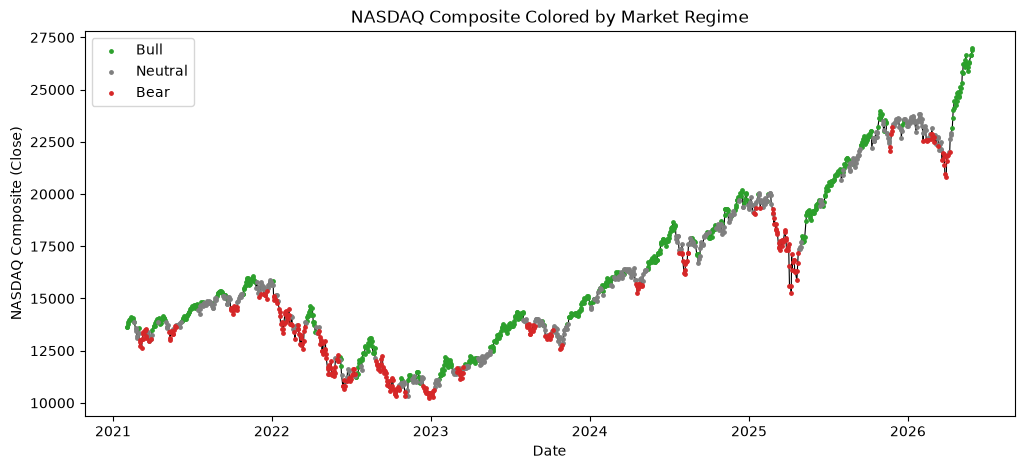

In [3]:
price_aligned = close.loc[regimes.index]
colors = {"Bull": "tab:green", "Neutral": "tab:gray", "Bear": "tab:red"}

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(price_aligned.index, price_aligned.values, color="black", linewidth=0.8, zorder=1)
for regime, color in colors.items():
    mask = (regimes == regime).values
    ax.scatter(price_aligned.index[mask], price_aligned.values[mask], color=color, s=6, label=regime, zorder=2)

ax.set_xlabel("Date")
ax.set_ylabel("NASDAQ Composite (Close)")
ax.set_title("NASDAQ Composite Colored by Market Regime")
ax.legend()
plt.show()

## Transition Probability Matrix

For consecutive trading days, estimate
$$P_{ij} = P(\text{Regime}_{t+1} = j \mid \text{Regime}_t = i)
= \frac{\#\{t : \text{Regime}_t = i,\ \text{Regime}_{t+1} = j\}}{\#\{t : \text{Regime}_t = i\}}$$

In [4]:
current = regimes.iloc[:-1].values
next_ = regimes.iloc[1:].values

counts = pd.DataFrame(0, index=states, columns=states)
for c, n in zip(current, next_):
    counts.loc[c, n] += 1

P = counts.div(counts.sum(axis=1), axis=0)
P

,Bull,Neutral,Bear
Bull,0.878843,0.121157,0.000000
Neutral,0.144086,0.750538,0.105376
Bear,0.000000,0.154088,0.845912


## Stationary Distribution

The stationary distribution $\pi$ satisfies $\pi P = \pi$, $\sum_i \pi_i = 1$ -- i.e. $\pi$ is
the left eigenvector of $P$ with eigenvalue 1. We compare it to the observed regime
frequencies.

In [5]:
eigvals, eigvecs = np.linalg.eig(P.values.T)
stationary = np.real(eigvecs[:, np.isclose(eigvals, 1)])
stationary = (stationary / stationary.sum()).flatten()

pd.DataFrame({
    "Stationary distribution": stationary,
    "Observed frequency": regimes.value_counts(normalize=True).reindex(states).values,
}, index=states)

,Stationary distribution,Observed frequency
Bull,0.413922,0.414361
Neutral,0.348054,0.347794
Bear,0.238024,0.237846


## Predicting the Next Regime

Given the most recently observed regime $i$, the most probable next regime is
$\arg\max_j P_{ij}$.

In [6]:
current_state = regimes.iloc[-1]
next_probs = P.loc[current_state]
predicted_next = next_probs.idxmax()

print(f"Current regime (last observed day): {current_state}")
print(f"\nP({current_state} -> next):")
print(next_probs)
print(f"\nMost probable next regime: {predicted_next}")

Current regime (last observed day): Bull

P(Bull -> next):
Bull       0.878843
Neutral    0.121157
Bear       0.000000
Name: Bull, dtype: float64

Most probable next regime: Bull


## Simulating the Markov Chain

Using $P$, simulate a regime sequence of the same length as the observed data (starting from
the first observed regime) and compare its state frequencies and average regime durations
(run lengths) to the observed sequence.

In [7]:
rng = np.random.default_rng(42)

n = len(regimes)
P_arr = P.values

sim = np.empty(n, dtype=int)
sim[0] = states.index(regimes.iloc[0])
for t in range(1, n):
    sim[t] = rng.choice(len(states), p=P_arr[sim[t - 1]])

sim_regimes = pd.Series([states[i] for i in sim], index=regimes.index)

freq_comparison = pd.DataFrame({
    "Observed": regimes.value_counts(normalize=True).reindex(states),
    "Simulated": sim_regimes.value_counts(normalize=True).reindex(states),
})
freq_comparison

,Observed,Simulated
Bull,0.414361,0.476440
Neutral,0.347794,0.300673
Bear,0.237846,0.222887


In [8]:
def avg_run_length(series, state):
    runs = []
    run_len = 0
    for val in series:
        if val == state:
            run_len += 1
        else:
            if run_len > 0:
                runs.append(run_len)
            run_len = 0
    if run_len > 0:
        runs.append(run_len)
    return np.mean(runs) if runs else 0.0

run_length_comparison = pd.DataFrame({
    "Observed": [avg_run_length(regimes, s) for s in states],
    "Simulated": [avg_run_length(sim_regimes, s) for s in states],
}, index=states)
run_length_comparison

,Observed,Simulated
Bull,8.147059,8.847222
Neutral,4.008621,3.322314
Bear,6.489796,5.960000


## Discussion

**Regime counts ($N=1337$ days):** Bull $= 554$ ($41.4\%$), Neutral $= 465$ ($34.8\%$),
Bear $= 318$ ($23.8\%$) -- consistent with NASDAQ being in a net uptrend over 2021-2026.

**Transition matrix:**
$$
P =
\begin{pmatrix}
0.879 & 0.121 & 0.000 \\
0.144 & 0.751 & 0.105 \\
0.000 & 0.154 & 0.846
\end{pmatrix}
\quad \text{(rows/cols: Bull, Neutral, Bear)}
$$

- All three regimes are **highly persistent**: $P(\text{Bull}\to\text{Bull}) = 0.879$,
  $P(\text{Neutral}\to\text{Neutral}) = 0.751$, $P(\text{Bear}\to\text{Bear}) = 0.846$.
- $P(\text{Bull}\to\text{Bear}) = P(\text{Bear}\to\text{Bull}) = 0$: the market never jumps
  directly between the two extremes in one day -- it always passes through Neutral.

**Stationary distribution** $\pi = (0.414,\ 0.348,\ 0.238)$ matches the observed frequencies
almost exactly, confirming the chain is essentially already at its long-run distribution over
this sample.

**Next-regime prediction:** the last observed day is in the **Bull** regime, and
$\arg\max_j P_{\text{Bull},j} = \text{Bull}$ with probability $0.879$ -- the model predicts
the market stays in Bull.

**Simulation vs. observed:** a simulated chain of the same length ($n=1337$) gives state
frequencies (Bull $0.476$ / Neutral $0.301$ / Bear $0.223$) and average regime durations
(Bull $8.8$ / Neutral $3.3$ / Bear $6.0$ days) reasonably close to the observed values
(Bull $8.1$ / Neutral $4.0$ / Bear $6.5$ days) -- a first-order Markov chain captures the
overall persistence of regimes reasonably well, with the remaining gap attributable to a
single finite simulation run.

**Caveat -- relation to Part I:** the very high diagonal probabilities mostly reflect *how
the regimes are constructed*, not new evidence of predictability. $R_t$ is a 20-day rolling
sum, so $R_t$ and $R_{t-1}$ share 19 of their 20 terms and are mechanically highly correlated
-- regimes therefore change slowly by construction. This is consistent with (not a
contradiction of) Part I's finding that *daily returns themselves* are essentially
unpredictable from lagged information: the regime label is a smoothed, slow-moving summary of
the recent past, while the next day's *return* remains close to white noise.